# Notebook 10 — Evaluate All 5 Models Across All Conditions

**Project:** MSc AI Dissertation — AI-Generated Text Detection  
**Student:** Abdul Hannaan Mohammed | B00409227 | UWS  

**What this notebook produces:**
- Evaluates all 5 models on HC3 test set (clean baseline)
- Evaluates all 5 models on Pegasus rewritten samples (adversarial)
- Evaluates all 5 models on QuillBot samples (if available)
- Evaluates all 5 models on ChatGPT rewritten samples (if available)
- Evaluates all 5 models on cross-dataset test (artem9k/ai-text-detection-pile)
- Saves all results to `results/metrics/all_results.csv`
- Produces all comparison charts for dissertation Chapter 5

> **DISSERTATION NOTE:** All outputs from this notebook go into Chapter 5 — Results and Evaluation

## 1. Imports, Paths and Seeds

In [10]:
import os, json, pickle, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams['figure.dpi'] = 150
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, confusion_matrix
)

NOTEBOOK_DIR    = os.path.dirname(os.path.abspath('__file__'))
PROJECT_ROOT    = os.path.dirname(NOTEBOOK_DIR)
DATA_PROCESSED  = os.path.join(PROJECT_ROOT, 'data', 'processed')
DATA_ADV        = os.path.join(PROJECT_ROOT, 'data', 'adversarial')
DATA_CROSS      = os.path.join(PROJECT_ROOT, 'data', 'raw', 'm4')
CHECKPOINTS_DIR = os.path.join(PROJECT_ROOT, 'models', 'checkpoints')
MODELS_DIR      = os.path.join(PROJECT_ROOT, 'models')
RESULTS_FIGS    = os.path.join(PROJECT_ROOT, 'results', 'figures')
RESULTS_METRICS = os.path.join(PROJECT_ROOT, 'results', 'metrics')
RESULTS_TABLES  = os.path.join(PROJECT_ROOT, 'results', 'tables')
RESULTS_CM      = os.path.join(PROJECT_ROOT, 'results', 'confusion_matrices')
SCREENSHOTS     = os.path.join(PROJECT_ROOT, 'results', 'screenshots')

for p in [RESULTS_FIGS, RESULTS_METRICS, RESULTS_TABLES, RESULTS_CM, SCREENSHOTS]:
    os.makedirs(p, exist_ok=True)

SEED   = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


## 2. Define All Models and All Datasets

In [11]:
# ── Model registry ─────────────────────────────────────────────────────────────
MODELS = {
    'RoBERTa-base'       : {'type': 'transformer', 'path': os.path.join(CHECKPOINTS_DIR, 'roberta-hc3-best')},
    'BERT-base'          : {'type': 'transformer', 'path': os.path.join(CHECKPOINTS_DIR, 'bert-hc3-best')},
    'DistilBERT'         : {'type': 'transformer', 'path': os.path.join(CHECKPOINTS_DIR, 'distilbert-hc3-best')},
    'Hello-SimpleAI'     : {'type': 'transformer', 'path': 'Hello-SimpleAI/chatgpt-detector-roberta'},
    'LogisticRegression' : {'type': 'sklearn',     'path': os.path.join(MODELS_DIR, 'logistic_regression', 'lr_model.pkl')},
}

# ── Dataset registry ───────────────────────────────────────────────────────────
# condition: 'balanced' = human+AI test, 'ai_only' = only AI samples (adversarial)
DATASETS = {
    'HC3-Clean'         : {'path': os.path.join(DATA_PROCESSED, 'test.csv'),                           'text_col': 'text',          'condition': 'balanced'},
    'Pegasus-Attack'    : {'path': os.path.join(DATA_ADV, 'pegasus_rewritten_500.csv'),               'text_col': 'rewritten_text', 'condition': 'ai_only'},
    'QuillBot-Attack'   : {'path': os.path.join(DATA_ADV, 'quillbot', 'quillbot_samples.csv'),        'text_col': 'rewritten_text', 'condition': 'ai_only'},
    'ChatGPT-Attack'    : {'path': os.path.join(DATA_ADV, 'chatgpt', 'chatgpt_samples.csv'),          'text_col': 'rewritten_text', 'condition': 'ai_only'},
    'Cross-Dataset'     : {'path': os.path.join(DATA_CROSS, 'cross_dataset_test.csv'),                'text_col': 'text',          'condition': 'balanced'},
}

print('Models registered:', list(MODELS.keys()))
print('Datasets registered:', list(DATASETS.keys()))

# Check which datasets are available
print('\nDataset availability:')
for name, info in DATASETS.items():
    exists = os.path.exists(info['path'])
    print(f'  {name:20s}: {"✅ Found" if exists else "❌ Missing — will skip"}')

Models registered: ['RoBERTa-base', 'BERT-base', 'DistilBERT', 'Hello-SimpleAI', 'LogisticRegression']
Datasets registered: ['HC3-Clean', 'Pegasus-Attack', 'QuillBot-Attack', 'ChatGPT-Attack', 'Cross-Dataset']

Dataset availability:
  HC3-Clean           : ✅ Found
  Pegasus-Attack      : ✅ Found
  QuillBot-Attack     : ✅ Found
  ChatGPT-Attack      : ✅ Found
  Cross-Dataset       : ✅ Found


## 3. Inference Utilities

In [12]:
MAX_LENGTH = 512
BATCH_SIZE = 16

class InferenceDataset(Dataset):
    """Simple dataset for inference — tokenises text on init."""
    def __init__(self, texts, tokeniser):
        self.encodings = tokeniser(
            texts, max_length=MAX_LENGTH,
            padding='max_length', truncation=True
        )
    def __len__(self):
        return len(self.encodings['input_ids'])
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx], dtype=torch.long)
                for k, v in self.encodings.items()}
        return item


def run_transformer_inference(texts, model_path):
    """Run inference with a HuggingFace transformer model.
    Returns (predictions, probabilities)."""
    tokeniser = AutoTokenizer.from_pretrained(model_path)
    model     = AutoModelForSequenceClassification.from_pretrained(model_path)
    model     = model.to(DEVICE)
    model.eval()

    dataset = InferenceDataset(texts, tokeniser)
    loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

    all_preds, all_probs = [], []
    with torch.no_grad():
        for batch in loader:
            inputs = {k: v.to(DEVICE) for k, v in batch.items()}
            logits = model(**inputs).logits
            probs  = torch.softmax(logits, dim=-1)[:, 1]
            preds  = torch.argmax(logits, dim=-1)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())

    # Free GPU memory
    del model
    torch.cuda.empty_cache()
    return all_preds, all_probs


def run_sklearn_inference(texts, model_path):
    """Run inference with a scikit-learn pipeline.
    Returns (predictions, probabilities)."""
    with open(model_path, 'rb') as f:
        pipeline = pickle.load(f)
    preds = pipeline.predict(texts).tolist()
    probs = pipeline.predict_proba(texts)[:, 1].tolist()
    return preds, probs


def compute_all_metrics(true_labels, preds, probs, condition):
    """Compute Accuracy, Precision, Recall, F1, ROC AUC.
    For ai_only conditions, only recall (detection rate) is meaningful."""
    if condition == 'ai_only':
        # Only AI samples — recall = detection rate
        true = [1] * len(preds)
        recall = sum(p == 1 for p in preds) / len(preds)
        return {
            'accuracy' : None,
            'precision': None,
            'recall'   : round(recall, 4),
            'f1'       : None,
            'roc_auc'  : None,
            'attack_success': round(1 - recall, 4)
        }
    else:
        acc = accuracy_score(true_labels, preds)
        p, r, f1, _ = precision_recall_fscore_support(
            true_labels, preds, average='binary', pos_label=1
        )
        try:
            auc = roc_auc_score(true_labels, probs)
        except Exception:
            auc = None
        return {
            'accuracy' : round(acc, 4),
            'precision': round(p,   4),
            'recall'   : round(r,   4),
            'f1'       : round(f1,  4),
            'roc_auc'  : round(auc, 4) if auc else None,
            'attack_success': None
        }

print('Inference utilities defined.')

Inference utilities defined.


## 4. Run All Evaluations

This cell runs all 5 models on all available datasets.  
**Expected time:** ~30–60 minutes depending on GPU speed.

> SCREENSHOT: Screenshot the progress output while running.  
> Save as: `results/screenshots/10_all_models_f1_comparison_clean.png`

In [13]:
all_results = []

for dataset_name, dataset_info in DATASETS.items():
    if not os.path.exists(dataset_info['path']):
        print(f'SKIP: {dataset_name} — file not found')
        continue

    print(f'\n{"="*55}')
    print(f'Dataset: {dataset_name}')
    print(f'{"="*55}')

    df = pd.read_csv(dataset_info['path'])

    # For adversarial datasets — filter to successful rewrites only
    if 'success' in df.columns:
        df = df[df['success'] == True].reset_index(drop=True)

    texts      = df[dataset_info['text_col']].astype(str).tolist()
    condition  = dataset_info['condition']
    true_labels = [1] * len(texts) if condition == 'ai_only' else df['label'].tolist()

    print(f'  Samples   : {len(texts)}')
    print(f'  Condition : {condition}')

    for model_name, model_info in MODELS.items():
        print(f'\n  → Running {model_name}...')
        try:
            if model_info['type'] == 'transformer':
                preds, probs = run_transformer_inference(texts, model_info['path'])
            else:
                preds, probs = run_sklearn_inference(texts, model_info['path'])

            metrics = compute_all_metrics(true_labels, preds, probs, condition)

            row = {
                'model'          : model_name,
                'dataset'        : dataset_name,
                'condition'      : condition,
                'n_samples'      : len(texts),
                'accuracy'       : metrics['accuracy'],
                'precision'      : metrics['precision'],
                'recall'         : metrics['recall'],
                'f1'             : metrics['f1'],
                'roc_auc'        : metrics['roc_auc'],
                'attack_success' : metrics['attack_success'],
            }
            all_results.append(row)

            if condition == 'ai_only':
                print(f'    Detection rate : {metrics["recall"]*100:.1f}%')
                print(f'    Attack success : {metrics["attack_success"]*100:.1f}%')
            else:
                print(f'    Accuracy  : {metrics["accuracy"]:.4f}')
                print(f'    F1        : {metrics["f1"]:.4f}')
                print(f'    ROC AUC   : {metrics["roc_auc"]}')

        except Exception as e:
            print(f'    ERROR: {e}')
            all_results.append({
                'model': model_name, 'dataset': dataset_name,
                'condition': condition, 'n_samples': len(texts),
                'accuracy': None, 'precision': None,
                'recall': None, 'f1': None,
                'roc_auc': None, 'attack_success': None
            })

print('\n\nAll evaluations complete!')


Dataset: HC3-Clean
  Samples   : 11820
  Condition : balanced

  → Running RoBERTa-base...
    Accuracy  : 0.9942
    F1        : 0.9913
    ROC AUC   : 0.9999

  → Running BERT-base...
    Accuracy  : 0.9895
    F1        : 0.9845
    ROC AUC   : 0.9999

  → Running DistilBERT...
    Accuracy  : 0.9948
    F1        : 0.9922
    ROC AUC   : 0.9999

  → Running Hello-SimpleAI...
    Accuracy  : 0.9953
    F1        : 0.9929
    ROC AUC   : 0.9997

  → Running LogisticRegression...
    Accuracy  : 0.9689
    F1        : 0.9524
    ROC AUC   : 0.9961

Dataset: Pegasus-Attack
  Samples   : 500
  Condition : ai_only

  → Running RoBERTa-base...
    Detection rate : 6.6%
    Attack success : 93.4%

  → Running BERT-base...
    Detection rate : 81.6%
    Attack success : 18.4%

  → Running DistilBERT...
    Detection rate : 72.8%
    Attack success : 27.2%

  → Running Hello-SimpleAI...
    Detection rate : 7.2%
    Attack success : 92.8%

  → Running LogisticRegression...
    Detection rat

## 5. Save Master Results CSV

In [14]:
results_df = pd.DataFrame(all_results)

csv_path = os.path.join(RESULTS_METRICS, 'all_results.csv')
results_df.to_csv(csv_path, index=False)

print('=== MASTER RESULTS TABLE ===')
print(results_df.to_string(index=False))
print(f'\nSaved: {csv_path}')

=== MASTER RESULTS TABLE ===
             model         dataset condition  n_samples  accuracy  precision  recall     f1  roc_auc  attack_success
      RoBERTa-base       HC3-Clean  balanced      11820    0.9942     0.9832  0.9995 0.9913   0.9999             NaN
         BERT-base       HC3-Clean  balanced      11820    0.9895     0.9697  0.9997 0.9845   0.9999             NaN
        DistilBERT       HC3-Clean  balanced      11820    0.9948     0.9850  0.9995 0.9922   0.9999             NaN
    Hello-SimpleAI       HC3-Clean  balanced      11820    0.9953     0.9882  0.9977 0.9929   0.9997             NaN
LogisticRegression       HC3-Clean  balanced      11820    0.9689     0.9689  0.9364 0.9524   0.9961             NaN
      RoBERTa-base  Pegasus-Attack   ai_only        500       NaN        NaN  0.0660    NaN      NaN           0.934
         BERT-base  Pegasus-Attack   ai_only        500       NaN        NaN  0.8160    NaN      NaN           0.184
        DistilBERT  Pegasus-Attack 

## 6. Chart: F1 Comparison — All Models on HC3 Clean

> SCREENSHOT: `results/screenshots/10_all_models_f1_comparison_clean.png` — Chapter 5

SCREENSHOT NOW: results/screenshots/10_all_models_f1_comparison_clean.png for Chapter 5


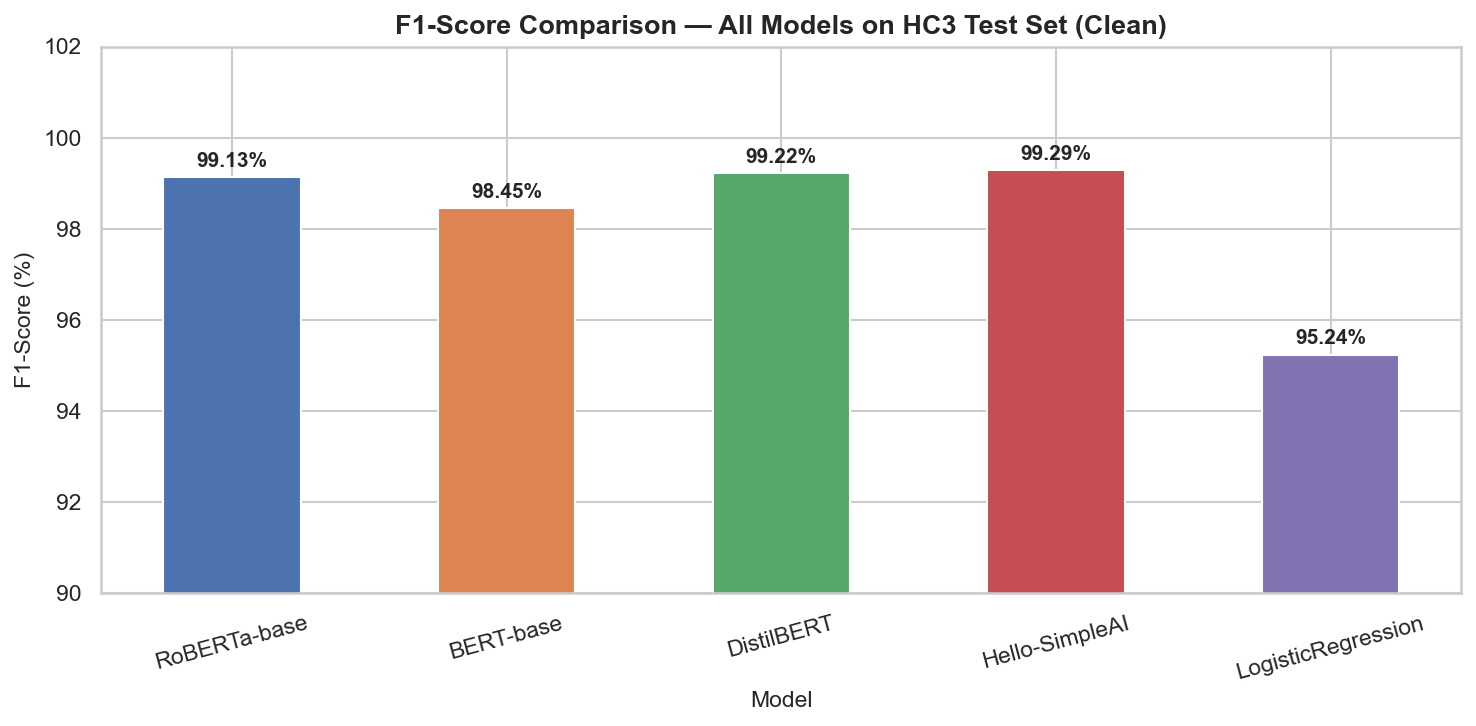

In [15]:
clean_df = results_df[results_df['dataset'] == 'HC3-Clean'].copy()

fig, ax = plt.subplots(figsize=(10, 5))
colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
bars    = ax.bar(clean_df['model'], clean_df['f1'] * 100,
                 color=colors[:len(clean_df)], edgecolor='white', width=0.5)

ax.set_title('F1-Score Comparison — All Models on HC3 Test Set (Clean)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('F1-Score (%)', fontsize=11)
ax.set_xlabel('Model', fontsize=11)
ax.set_ylim(90, 102)
ax.bar_label(bars, labels=[f'{v:.2f}%' for v in clean_df['f1'] * 100],
             padding=3, fontsize=10, fontweight='bold')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
path = os.path.join(RESULTS_FIGS, 'fig_all_models_f1_clean.png')
plt.savefig(path, bbox_inches='tight', dpi=150)
print(f'SCREENSHOT NOW: results/screenshots/10_all_models_f1_comparison_clean.png for Chapter 5')
plt.show()

## 7. Chart: Attack Success Rate — All Models vs All Attacks

> SCREENSHOT: `results/screenshots/11_all_models_f1_comparison_attacked.png` — Chapter 5

SCREENSHOT NOW: results/screenshots/11_all_models_f1_comparison_attacked.png for Chapter 5


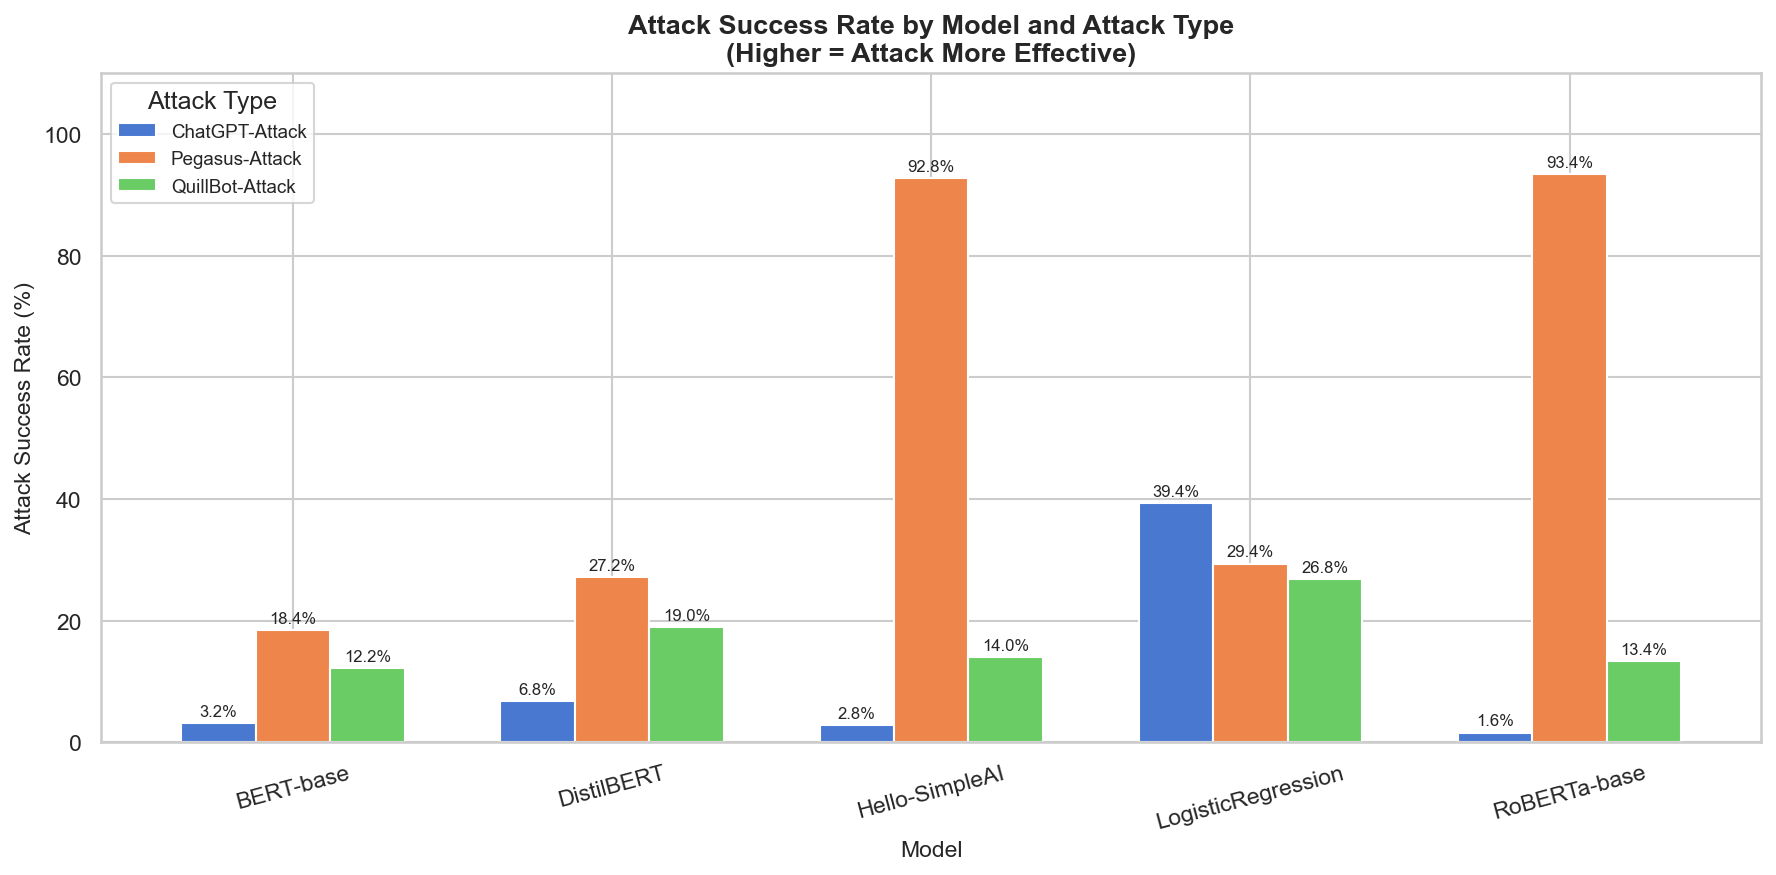

In [16]:
attack_df = results_df[results_df['condition'] == 'ai_only'].copy()

if len(attack_df) > 0:
    pivot = attack_df.pivot(index='model', columns='dataset', values='attack_success') * 100

    fig, ax = plt.subplots(figsize=(12, 6))
    pivot.plot(kind='bar', ax=ax, edgecolor='white', width=0.7)

    ax.set_title('Attack Success Rate by Model and Attack Type\n(Higher = Attack More Effective)',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Attack Success Rate (%)', fontsize=11)
    ax.set_xlabel('Model', fontsize=11)
    ax.set_ylim(0, 110)
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='Attack Type', fontsize=9)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=8, padding=2)

    plt.tight_layout()
    path = os.path.join(RESULTS_FIGS, 'fig_all_models_attack_comparison.png')
    plt.savefig(path, bbox_inches='tight', dpi=150)
    print(f'SCREENSHOT NOW: results/screenshots/11_all_models_f1_comparison_attacked.png for Chapter 5')
    plt.show()
else:
    print('No adversarial results yet — run QuillBot and ChatGPT attacks first.')

## 8. Heatmap: Performance Degradation

> SCREENSHOT: `results/screenshots/17_performance_degradation_heatmap.png` — Chapter 5

SCREENSHOT NOW: results/screenshots/17_performance_degradation_heatmap.png for Chapter 5


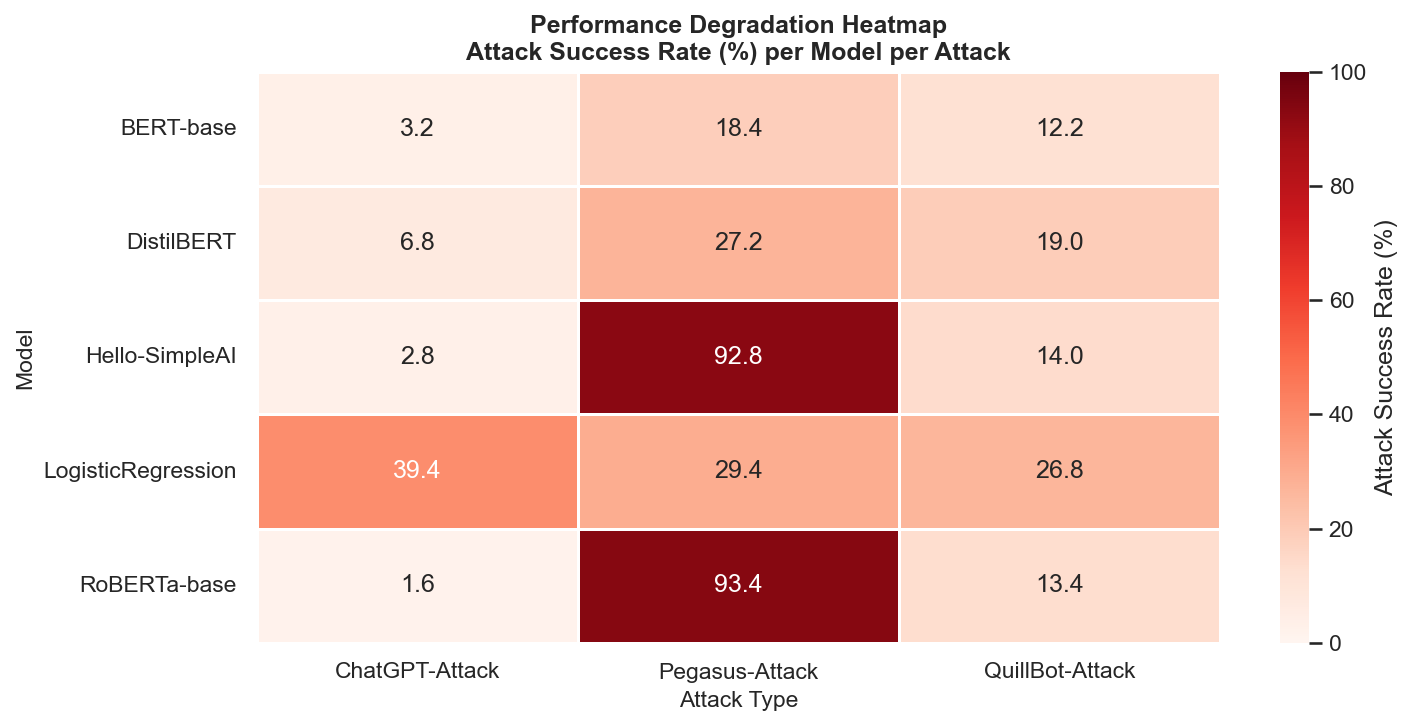

In [17]:
attack_df = results_df[results_df['condition'] == 'ai_only'].copy()

if len(attack_df) > 0:
    heatmap_data = attack_df.pivot(index='model', columns='dataset', values='attack_success') * 100

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(
        heatmap_data, annot=True, fmt='.1f', cmap='Reds',
        ax=ax, linewidths=0.5, annot_kws={'size': 12},
        vmin=0, vmax=100, cbar_kws={'label': 'Attack Success Rate (%)'}
    )
    ax.set_title('Performance Degradation Heatmap\nAttack Success Rate (%) per Model per Attack',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Attack Type', fontsize=11)
    ax.set_ylabel('Model', fontsize=11)

    plt.tight_layout()
    path = os.path.join(RESULTS_FIGS, 'fig_performance_degradation_heatmap.png')
    plt.savefig(path, bbox_inches='tight', dpi=150)
    print(f'SCREENSHOT NOW: results/screenshots/17_performance_degradation_heatmap.png for Chapter 5')
    plt.show()
else:
    print('Run QuillBot and ChatGPT attacks first to complete the heatmap.')

## 9. Chart: Cross-Dataset Results

> SCREENSHOT: `results/screenshots/18_m4_cross_dataset_results.png` — Chapter 5

SCREENSHOT NOW: results/screenshots/18_m4_cross_dataset_results.png for Chapter 5


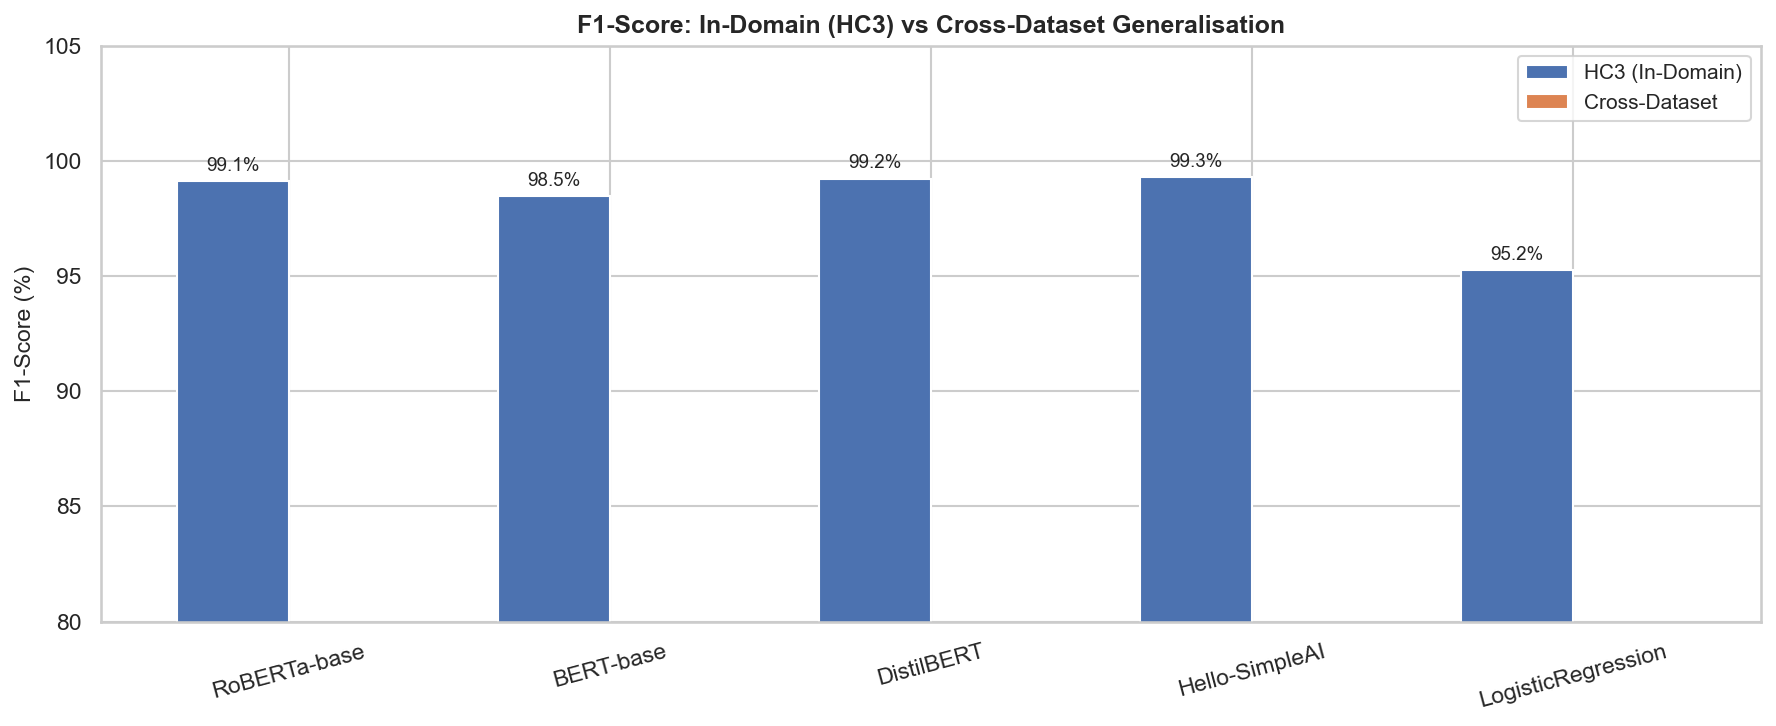

In [18]:
cross_df = results_df[results_df['dataset'] == 'Cross-Dataset'].copy()
hc3_df   = results_df[results_df['dataset'] == 'HC3-Clean'].copy()

if len(cross_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    x     = np.arange(len(cross_df))
    width = 0.35

    b1 = ax.bar(x - width/2, hc3_df['f1'] * 100,   width, label='HC3 (In-Domain)',    color='#4C72B0', edgecolor='white')
    b2 = ax.bar(x + width/2, cross_df['f1'] * 100,  width, label='Cross-Dataset',      color='#DD8452', edgecolor='white')

    ax.set_title('F1-Score: In-Domain (HC3) vs Cross-Dataset Generalisation',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('F1-Score (%)', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(cross_df['model'], rotation=15)
    ax.set_ylim(80, 105)
    ax.legend(fontsize=10)
    ax.bar_label(b1, labels=[f'{v:.1f}%' for v in hc3_df['f1'] * 100],   padding=3, fontsize=9)
    ax.bar_label(b2, labels=[f'{v:.1f}%' for v in cross_df['f1'] * 100],  padding=3, fontsize=9)

    plt.tight_layout()
    path = os.path.join(RESULTS_FIGS, 'fig_cross_dataset_comparison.png')
    plt.savefig(path, bbox_inches='tight', dpi=150)
    print(f'SCREENSHOT NOW: results/screenshots/18_m4_cross_dataset_results.png for Chapter 5')
    plt.show()
else:
    print('Cross-dataset results not available.')

## 10. Summary

### Files produced
| File | Location | Dissertation |
|------|----------|--------------|
| `all_results.csv` | `results/metrics/` | Master results table |
| `fig_all_models_f1_clean.png` | `results/figures/` | Figure — Chapter 5 |
| `fig_all_models_attack_comparison.png` | `results/figures/` | Figure — Chapter 5 |
| `fig_performance_degradation_heatmap.png` | `results/figures/` | Figure — Chapter 5 |
| `fig_cross_dataset_comparison.png` | `results/figures/` | Figure — Chapter 5 |

### Next step
Complete **QuillBot** and **ChatGPT** manual rewriting (100 samples each), save the CSVs, then rerun Cell 4 to add those results to `all_results.csv`.